# Nominal Roll Vector Field

Compute `m4opt.dynamics.nominal_roll` for every field in the mission's
skygrid over a range of times and plot it as an animated vector field on the
sky, alongside the ecliptic plane and the Sun's position. `roll=0` means the
spacecraft's +Z axis points at celestial north (see the `nominal_roll`
docstring); arrows are headless line segments (whiskers) at each field
showing the roll direction, colored by roll angle with a cyclic colormap so
that sharp color jumps between neighboring arrows flag an orientation
discontinuity even before looking at the arrow directions themselves.

`nominal_roll` picks the roll that keeps the Sun perpendicular to the
spacecraft's solar-panel axis (see its docstring / source: the roll is built
from `target_coord x sun_direction`), so the field is only ill-defined where
that cross product vanishes -- i.e. exactly at the Sun's position and at the
anti-Sun point, not at the celestial or ecliptic poles. Plotting the Sun's
position directly on the field makes this easy to confirm by eye.

## Setup and Configuration

In [1]:
# ========================================= #
# Manage Warnings                           #
# ========================================= #
import warnings

warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", ".*dubious year.*")
warnings.filterwarnings(
    "ignore", "Tried to get polar motions for times after IERS data is valid.*"
)

In [2]:
# ========================================= #
# Imports                                   #
# ========================================= #
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import Angle, GeocentricMeanEcliptic, SkyCoord, get_body
from astropy.time import Time
from ligo.skymap import plot  # noqa: F401
from m4opt.dynamics import nominal_roll
from m4opt.missions import uvex as mission
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection

In [3]:
# ========================================= #
# Settings and Configuration                #
# ========================================= #

# --- CORE SETTINGS --- #

OUTPUT_PATH = Path("../Runs/TEST")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
START_TIME = Time("2030-01-01T00:00:00")
END_TIME = Time("2031-01-01T00:00:00")
N_STEPS = 60

# --- SKYGRID SETTINGS --- #
# The mission's own built-in candidate-pointing grid. (No RA cut needed here
# -- the RA=0/360 meridian is handled properly by roll_field_collection
# below, so the whole sky can be kept.)
SKYGRID = mission.skygrid
PLOT_CENTER_RA = 180 * u.deg  # match whatever `center=` (if any) you pass to the axis
PLOT_CENTER_DEC = 0 * u.deg

# --- ARROW SETTINGS --- #
# Angular length of each roll-direction whisker. Set close to the typical
# skygrid spacing so neighboring arrows are visually comparable without
# overlapping.
ARROW_LENGTH = 3 * u.deg

# Cut the skygrid down.
dra = Angle(SKYGRID.ra - PLOT_CENTER_RA).wrap_at(180 * u.deg)
ddec = Angle(SKYGRID.dec - PLOT_CENTER_DEC).wrap_at(180 * u.deg)
distance_from_edge_ra = 180 * u.deg - np.abs(dra)
distance_from_edge_dec = 180 * u.deg - np.abs(ddec)
distance_from_edge = np.minimum(distance_from_edge_ra, distance_from_edge_dec)
SKYGRID = SKYGRID[distance_from_edge > 10 * ARROW_LENGTH]

# --- COLOR SETTINGS --- #
# Roll is a periodic quantity, so use a cyclic colormap; sharp color jumps
# between neighboring points flag an orientation discontinuity even before
# looking at the arrow directions themselves.
CMAP = "hsv"
ECLIPTIC_COLOR = "goldenrod"
SUN_COLOR = "gold"

# --- POLE ZOOM SETTINGS --- #
# Minimum |declination| for a field to be included in the pole zoom plots.
POLE_ZOOM_MIN_ABS_DEC = 60 * u.deg

# --- ANIMATION SETTINGS --- #
ANIMATION_PATH = OUTPUT_PATH / "roll_vector_field.mp4"
ANIMATION_DPI = 120
ANIMATION_INTERVAL = 150  # milliseconds between frames

## Helper Functions

In [4]:
def break_at_wrap(ra_deg, dec_deg):
    """Insert a NaN wherever a curve's RA jumps by more than 180 deg.

    matplotlib draws a straight line between consecutive points in data
    space, so a curve that legitimately crosses the RA=0/360 meridian (e.g.
    the ecliptic) would otherwise be drawn as a spurious line all the way
    across the plot. A NaN breaks the line at that point instead.
    """
    ra_deg = np.asarray(ra_deg, dtype=float)
    dec_deg = np.asarray(dec_deg, dtype=float)
    jumps = np.flatnonzero(np.abs(np.diff(ra_deg)) > 180)
    return np.insert(ra_deg, jumps + 1, np.nan), np.insert(dec_deg, jumps + 1, np.nan)


def unwrap_tip_ra(coords, tip_coords):
    """RA of each whisker tip, unwrapped to the branch nearest its own field.

    Whiskers are short (``ARROW_LENGTH``), so a tip's RA should never be far
    from its field's RA. Without this, a whisker that happens to straddle
    the RA=0/360 meridian gets drawn as a long line jumping across the whole
    plot instead of a short local arrow.
    """
    dra = Angle(tip_coords.ra - coords.ra).wrap_at(180 * u.deg)
    return coords.ra + dra


def roll_field_collection(coords, tip_coords, roll_values_deg, **kwargs):
    """Build a LineCollection of roll-direction whiskers for a set of fields."""
    tip_ra = unwrap_tip_ra(coords, tip_coords)
    segments = np.stack(
        [
            np.column_stack([coords.ra.deg, coords.dec.deg]),
            np.column_stack([tip_ra.deg, tip_coords.dec.deg]),
        ],
        axis=1,
    )
    return LineCollection(
        segments, array=roll_values_deg, cmap=CMAP, norm=plt.Normalize(0, 360), **kwargs
    )


def compute_roll_field(t):
    """Observer location, per-field roll, whisker tips, and apparent Sun direction."""
    observer_location = mission.observer_location(t)

    roll = nominal_roll(observer_location, SKYGRID, t)
    roll_deg = Angle(roll).wrap_at(360 * u.deg).to_value(u.deg)

    tips = SKYGRID.directional_offset_by(roll, ARROW_LENGTH)

    # Apparent observer-to-Sun direction.
    # Do NOT transform this finite-distance coordinate to ICRS:
    # that changes the coordinate origin from geocentric to barycentric.
    sun = get_body("sun", t, observer_location)

    return roll_deg, tips, sun


# The ecliptic plane in ICRS -- essentially fixed over the timescales here,
# so it only needs to be computed once, at the start of the time range.
ECLIPTIC = SkyCoord(
    np.linspace(0, 360, 361) * u.deg,
    0 * u.deg,
    frame=GeocentricMeanEcliptic(equinox=START_TIME),
).icrs
ECLIPTIC_RA_PLOT, ECLIPTIC_DEC_PLOT = break_at_wrap(ECLIPTIC.ra.deg, ECLIPTIC.dec.deg)

## Whole-Sky Vector Field (Single Time)

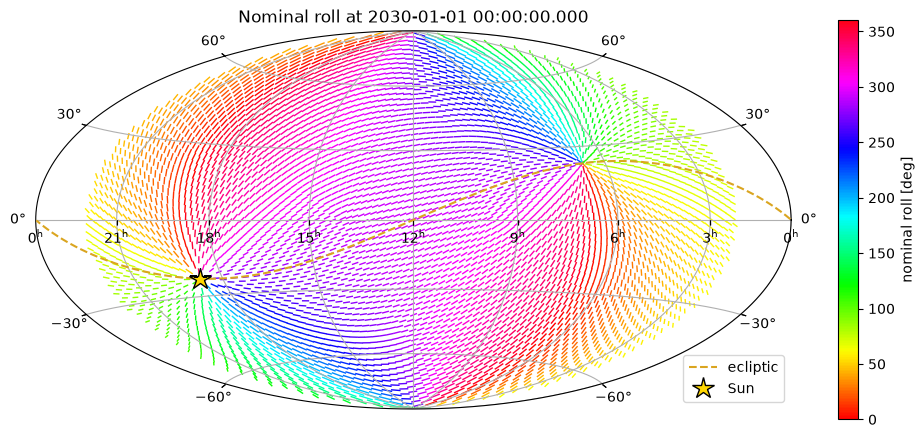

In [5]:
roll_deg0, tips0, sun0 = compute_roll_field(START_TIME)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection="astro aitoff")
ax.grid()
ax.set_title(f"Nominal roll at {START_TIME.iso}")

transform = ax.get_transform("world")
lc = roll_field_collection(
    SKYGRID, tips0, roll_deg0, linewidths=1, transform=transform, zorder=1
)
ax.add_collection(lc)
ax.plot(
    ECLIPTIC_RA_PLOT,
    ECLIPTIC_DEC_PLOT,
    "--",
    color=ECLIPTIC_COLOR,
    linewidth=1.5,
    transform=transform,
    zorder=2,
    label="ecliptic",
)
ax.plot(
    sun0.ra.deg,
    sun0.dec.deg,
    "*",
    color=SUN_COLOR,
    markersize=16,
    markeredgecolor="k",
    transform=transform,
    zorder=3,
    label="Sun",
)
fig.colorbar(lc, ax=ax, label="nominal roll [deg]", shrink=0.7)
ax.legend(loc="lower right")
fig.tight_layout()

## Zoomed View Near the Poles

The all-sky projection compresses the polar caps, so zoom in on each pole
specifically. Since the roll field's singularities sit at the Sun and
anti-Sun points (see above), the poles themselves should show a smoothly
varying pinwheel of color with no discontinuity, *unless* the Sun happens to
pass near one of them at the chosen time (it never does, for a fixed
ecliptic-plane Sun and celestial poles ~66.5 deg off the ecliptic).

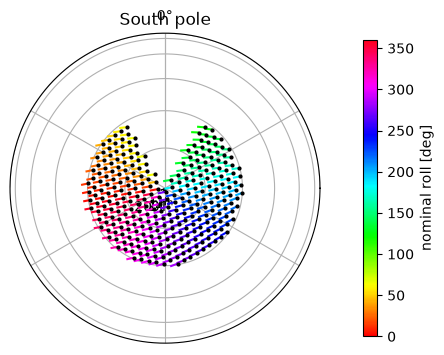

In [6]:
def plot_pole(ax, dec_sign):
    sel = (SKYGRID.dec * dec_sign) > POLE_ZOOM_MIN_ABS_DEC
    ax.set_title(("North" if dec_sign > 0 else "South") + " pole")
    ax.grid()
    lc = roll_field_collection(
        SKYGRID[sel],
        tips0[sel],
        roll_deg0[sel],
        linewidths=1.5,
        transform=ax.get_transform("world"),
    )
    ax.add_collection(lc)
    ax.scatter(
        SKYGRID.ra.deg[sel],
        SKYGRID.dec.deg[sel],
        s=4,
        color="k",
        transform=ax.get_transform("world"),
        zorder=3,
    )
    return lc


fig = plt.figure(figsize=(11, 5.5))
ax_north = fig.add_subplot(
    1, 2, 1, projection="astro globe", center=SkyCoord(0 * u.deg, 90 * u.deg)
)
ax_south = fig.add_subplot(
    1, 2, 2, projection="astro globe", center=SkyCoord(0 * u.deg, -90 * u.deg)
)

lc_north = plot_pole(ax_north, 1)
plot_pole(ax_south, -1)

fig.colorbar(lc_north, ax=[ax_north, ax_south], label="nominal roll [deg]", shrink=0.7)

## Animation Over Time

Step from `START_TIME` to `END_TIME` in `N_STEPS` steps, recomputing the
roll field and the Sun's position at each step, and save the result to
`ANIMATION_PATH`. The whiskers should visibly pivot in lockstep as the Sun
moves along the ecliptic.

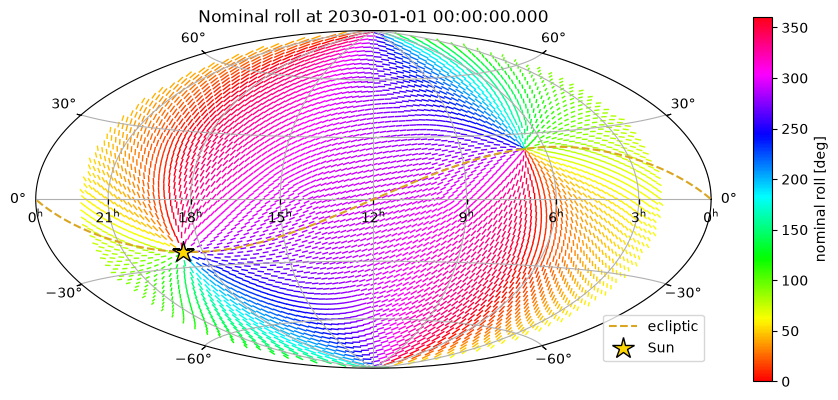

In [7]:
TIMES = START_TIME + np.linspace(0, 1, N_STEPS) * (END_TIME - START_TIME)

fig = plt.figure(figsize=(9, 5.5))
ax = fig.add_subplot(projection="astro aitoff")
ax.grid()
transform = ax.get_transform("world")

ax.plot(
    ECLIPTIC_RA_PLOT,
    ECLIPTIC_DEC_PLOT,
    "--",
    color=ECLIPTIC_COLOR,
    linewidth=1.5,
    transform=transform,
    zorder=2,
    label="ecliptic",
)

roll_deg_i, tips_i, sun_i = compute_roll_field(TIMES[0])
lc = roll_field_collection(
    SKYGRID, tips_i, roll_deg_i, linewidths=1, transform=transform, zorder=1
)
ax.add_collection(lc)
(sun_artist,) = ax.plot(
    sun_i.ra.deg,
    sun_i.dec.deg,
    "*",
    color=SUN_COLOR,
    markersize=16,
    markeredgecolor="k",
    transform=transform,
    zorder=3,
    label="Sun",
)
ax.legend(loc="lower right")
title = ax.set_title(f"Nominal roll at {TIMES[0].iso}")
fig.colorbar(lc, ax=ax, label="nominal roll [deg]", shrink=0.7)
fig.tight_layout()


def animate(i):
    t = TIMES[i]
    roll_deg_i, tips_i, sun_i = compute_roll_field(t)
    tip_ra_i = unwrap_tip_ra(SKYGRID, tips_i)
    segments = np.stack(
        [
            np.column_stack([SKYGRID.ra.deg, SKYGRID.dec.deg]),
            np.column_stack([tip_ra_i.deg, tips_i.dec.deg]),
        ],
        axis=1,
    )
    lc.set_segments(segments)
    lc.set_array(roll_deg_i)
    sun_artist.set_data([sun_i.ra.deg], [sun_i.dec.deg])
    title.set_text(f"Nominal roll at {t.iso}")
    return [lc, sun_artist, title]


ANIMATION_PATH.parent.mkdir(parents=True, exist_ok=True)
ani = FuncAnimation(
    fig, animate, frames=N_STEPS, interval=ANIMATION_INTERVAL, blit=False
)
ani.save(ANIMATION_PATH, dpi=ANIMATION_DPI)